Tyler Fields

CSCI 4650

Homework 4

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt

def newtdd_inplace( x, y ):
    n = len( x )
    for i in range(1,n):
        for j in range(n-i-1,-1,-1):
            y[j+i] = ( y[j+i] - y[j+i-1] ) / ( x[j+i] - x[j] )
    return y

def newtdd( x, y ):
    c = copy.deepcopy( y )
    newtdd_inplace( x, c )
    return c

def polyval_nested_w_base_points( c, b, x ):
  d = np.size(c)
  px = c[ d-1 ] * np.ones( np.shape(x) )
  for i in range( d-2, -1, -1 ):
    px = px * ( x - b[i] ) + c[i]
  return px

In [ ]:
# ------------------
# Exercise EX.3.1.18
# ------------------

# The expected lifetime of an industrial fan when operated at the listed temperature is shown in the table that
# follows. Estimate the lifetime at 70oC by using (a) the parabola from the last three data points (b) the degree-3
# curve using all four points.

#    temp (C) | hrs (x1000)
#    -------------------
#        25 | 95
#        40 | 75
#        50 | 63
#        60 | 54

x = np.array([40., 50., 60.])
y = np.array([75., 63., 54.])

c = newtdd(x, y)
print("Parabola coefficients (last 3 points):")
print(c)
print("p(70) from parabola =", f"{polyval_nested_w_base_points(c, x, 70):8.2f}")

Parabola coefficients (last 3 points):
[ 7.5e+01 -1.2e+00  1.5e-02]
p(70) from parabola =    48.00


In [ ]:
# (b)

x = np.array([25., 40., 50., 60.])
y = np.array([ 95., 75., 63., 54.])

c = newtdd( x, y )
print("coefficients of interpolating polynomial in nested form")
print("from degree 0 to higest degree:\n",c)

yy = polyval_nested_w_base_points( c, x, x )
err = abs( yy - y )
print("---------------------------------------------------------------------")
print("|    x     |          y           |          p(x)        |  error   |")
print("---------------------------------------------------------------------")
for i in range(0,len(x)):
    print("|",f"{x[i]: 8.1f}","|", f"{y[i]: 20.16f}","|", f"{yy[i]: 20.16f}","|", f"{err[i]: 3.1e}","|")
print("---------------------------------------------------------------------")

print( "absolute error = ",  f"{np.linalg.norm( y - yy, np.inf):6.1e}" )

print( "p(70) actual = ",  f"{polyval_nested_w_base_points( c, x, 70 ):8.2f}" )

coefficients of interpolating polynomial in nested form
from degree 0 to higest degree:
 [ 9.50000000e+01 -1.33333333e+00  5.33333333e-03  2.76190476e-04]
---------------------------------------------------------------------
|    x     |          y           |          p(x)        |  error   |
---------------------------------------------------------------------
|     25.0 |  95.0000000000000000 |  95.0000000000000000 |  0.0e+00 |
|     40.0 |  75.0000000000000000 |  75.0000000000000000 |  0.0e+00 |
|     50.0 |  63.0000000000000000 |  63.0000000000000000 |  0.0e+00 |
|     60.0 |  54.0000000000000000 |  54.0000000000000000 |  0.0e+00 |
---------------------------------------------------------------------
absolute error =  0.0e+00
p(70) actual =     49.66


---------------------------------------------
|    x    |  cos x   | cos1(x)  |   error    |
---------------------------------------------
|     1.0 |   0.5403 |   0.5399 |     0.0004 |
|     2.0 |  -0.4161 |  -0.4169 |     0.0008 |
|     3.0 |  -0.9900 |  -0.9922 |     0.0022 |
|     4.0 |  -0.6536 |  -0.6525 |     0.0011 |
|    14.0 |   0.1367 |   0.1384 |     0.0017 |
|  1000.0 |   0.5624 |   0.5618 |     0.0005 |
---------------------------------------------
max absolute error = 2.2e-03
it seems like all is well!


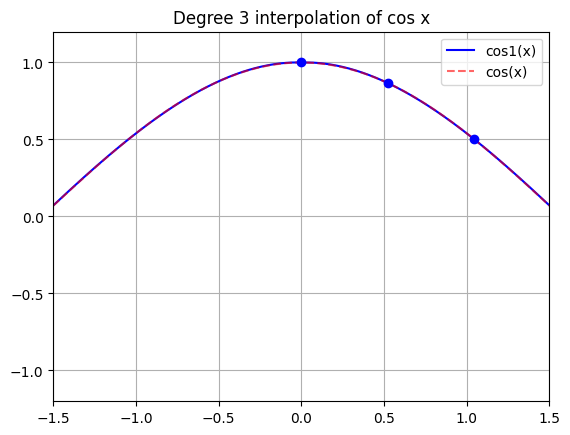

In [ ]:
# ---------------------
# Exercise CP.3.1.4
# ---------------------

def cos1(x):
  # Build the interpolating polynomial and store coefficients
  x = np.asarray(x, dtype=float)
  b = np.pi * np.arange(4) / 6      # base points: 0, pi/6, pi/3, pi/2
  yb = np.cos(b)
  c = newtdd(b, yb)

  # Move x to the fundamental domain and evaluate the polynomial
  s = np.ones_like(x)
  x1 = np.mod(x, 2 * np.pi)

  x1 = np.where(x1 > np.pi, 2 * np.pi - x1, x1)

  mask = x1 > np.pi / 2
  x1 = np.where(mask, np.pi - x1, x1)
  s = np.where(mask, -1, s)

  y = s * polyval_nested_w_base_points(c, b, x1)
  return y

# Test points
x = np.array([1., 2., 3., 4., 14., 1000.])

y_true = np.cos(x)
y_approx = cos1(x)
err = np.abs(y_true - y_approx)

print("---------------------------------------------")
print("|    x    |  cos x   | cos1(x)  |   error    |")
print("---------------------------------------------")
for i in range(len(x)):
    print("|", f"{x[i]: 7.1f}", "|", f"{y_true[i]: 8.4f}", "|",
          f"{y_approx[i]: 8.4f}", "|", f"{err[i]: 10.4f}", "|")
print("---------------------------------------------")

print("max absolute error =", f"{np.linalg.norm(y_true - y_approx, np.inf):6.1e}")

# Correctness check
allgood = np.allclose(cos1(x), np.cos(x), atol=1e-2)
if allgood:
    print("it seems like all is well!")
else:
    print("there might be an issue")

# Plot
xx = np.linspace(-1.5, 1.5, 1000)
yy = cos1(xx)

plt.plot(xx, yy, '-b', label='cos1(x)')
plt.plot(xx, np.cos(xx), '--r', label='cos(x)', alpha=0.6)

b = np.pi * np.arange(4) / 6
plt.plot(b, np.cos(b), 'ob')

plt.xlim([-1.5, 1.5])
plt.ylim([-1.2, 1.2])
plt.grid()
plt.legend()
plt.title("Degree 3 interpolation of cos x")
plt.show()